In [1677]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function
from poi.modes import fourier_modes_sequence

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Wedge
from scipy.ndimage import rotate

In [1678]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 22
act_pitch = 3
samples_per_act = 21
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(0,0))

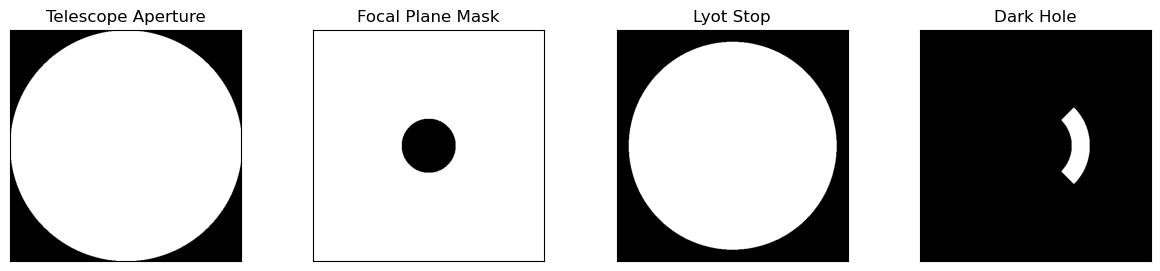

In [1679]:
Npup = 512
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 4
OWA = 6
CORO_IWA = 3
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi < -np.pi / 4] = 0
dark_hole[psi > np.pi / 4] = 0

FPM = np.ones_like(u)
FPM[ rho < CORO_IWA] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[15,3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.xticks([],[])
plt.yticks([],[])
plt.title('Telescope Aperture')
plt.subplot(142)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(143)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(144)
plt.imshow(dark_hole, cmap='gray')
plt.title('Dark Hole')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

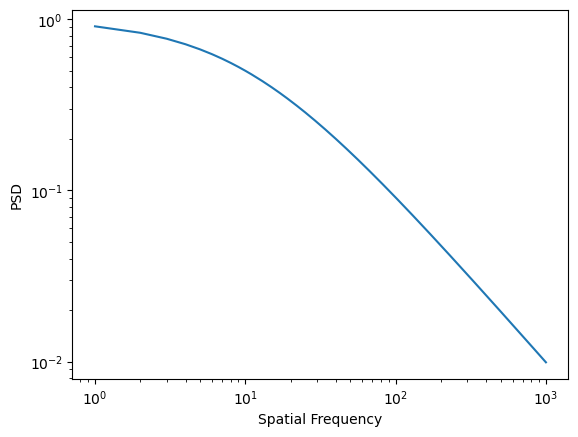

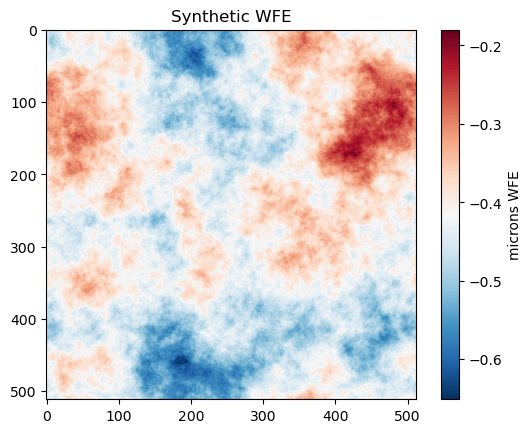

In [1680]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

# Just picked ABC values until it looked about right
Npup = Nout
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

In [1681]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    x, y = make_xy_grid(z.shape, dx=10/Npup)
    cosine_wfe = np.sin(3*x + y) / 50
    wfe = np.exp(1j * 2 * np.pi / WVL * (pupil_wfe + cosine_wfe))
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


# Compute image center from satelite spots

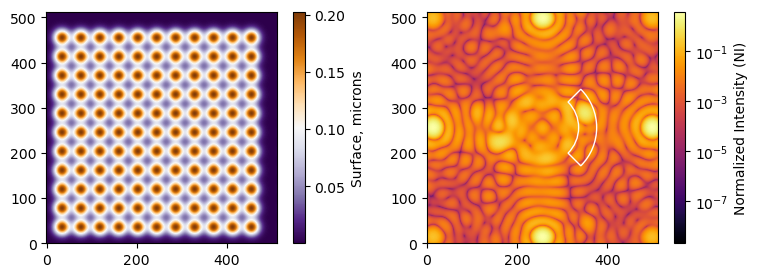

In [1682]:
waffle = np.ones_like(dm.actuators) * 1e-1
for i in range(dm.actuators.shape[0]):
    for j in range(dm.actuators.shape[1]):

        if i%2 != 0 or j%2 != 0:
            waffle[i,j] = 0

dm.actuators[:] += waffle

plt.figure(figsize=[9,3])
plt.subplot(121)
plt.imshow(dm.render(), cmap="PuOr_r", origin="lower")
plt.colorbar(label="Surface, microns")
plt.subplot(122)
waffle_image = snap_image(dm.render(wfe=True))
plt.imshow(waffle_image, cmap="inferno", norm=LogNorm(), origin="lower")
plt.colorbar(label="Normalized Intensity (NI)")
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.show()
dm.actuators[:] -= waffle
dm.actuators[:] = 0

In [1683]:
from poi.speckle_nulling import find_image_center, compute_pixel_scale_lamd

row_cen, col_cen = find_image_center(waffle_image)
dx_lamD_empirical = 1/compute_pixel_scale_lamd(waffle_image, waffle_frequency=nact//2)
print(dx_lamD_empirical)
print((dx_img * um_to_LD))

0.05763635799212671
0.05


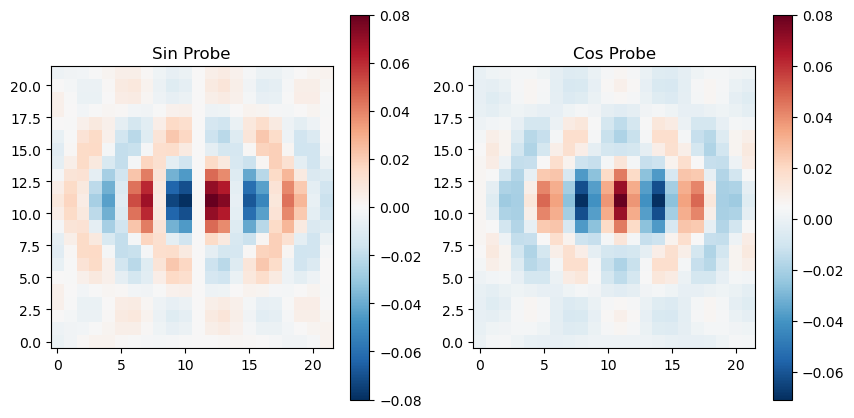

In [1684]:
# Derive cosine and sine modes from Oya et al.
kfreq = 2 * np.pi / (WVL * EFL * 1e-3)

# define a focal plane in m
xm, ym = make_xy_grid(waffle_image.shape, dx=dx_img)

# Find the sinusoidal frequencies in x and y
xfreq = (kfreq * xm)[dark_hole==1]
yfreq = (kfreq * ym)[dark_hole==1]

# get the modes
xdm, ydm = make_xy_grid(dm.Nact, dx=act_pitch * 1e-3)
xdm /= 8
ydm /= 8

V1 = np.sin(xfreq[..., None, None] * xdm + yfreq[..., None, None] * ydm)
V2 = np.cos(xfreq[..., None, None] * xdm + yfreq[..., None, None] * ydm)
# V2 = np.swapaxes(V2, 1, 2)

V1sum = np.sum(V1, axis=0)
V2sum = np.sum(V2, axis=0)

V1norm = V1sum.max()
V2norm = V2sum.max()
V0 = 8e-2

V1sum *= V0 / V1norm
V2sum *= V0 / V2norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(V1sum, cmap="RdBu_r", origin="lower")
plt.colorbar()
plt.title("Sin Probe")
plt.subplot(122)
plt.imshow(V2sum, cmap="RdBu_r", origin="lower")
plt.colorbar()
plt.title("Cos Probe")
plt.show()

sin_probe = V1sum
cos_probe = V2sum



In [1685]:
diff_imgs = []
dm_surfs = []
fwd_imgs = []

# clear dm
dm.actuators[:] = 0

for probe in [sin_probe, cos_probe]:
    dm.actuators[:] += probe
    img1 = snap_image(dm.render(wfe=True))
    img2 = snap_image(-dm.render(wfe=True))
    diff_imgs.append(img1-img2)
    fwd_imgs.append(img1)
    dm_surfs.append(dm.render())
    dm.actuators[:] -= probe

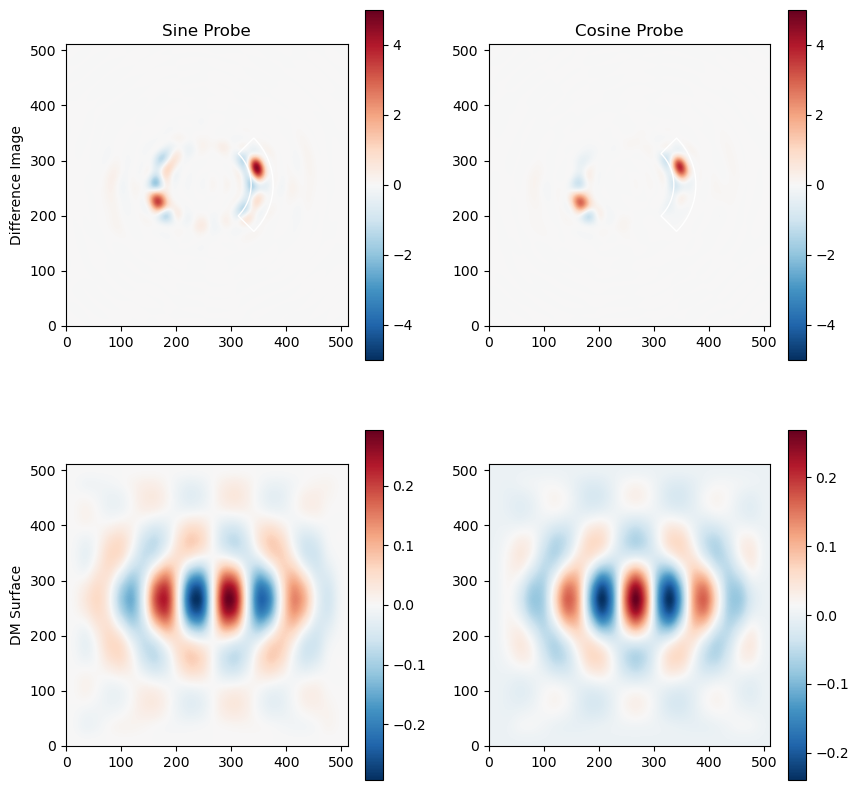

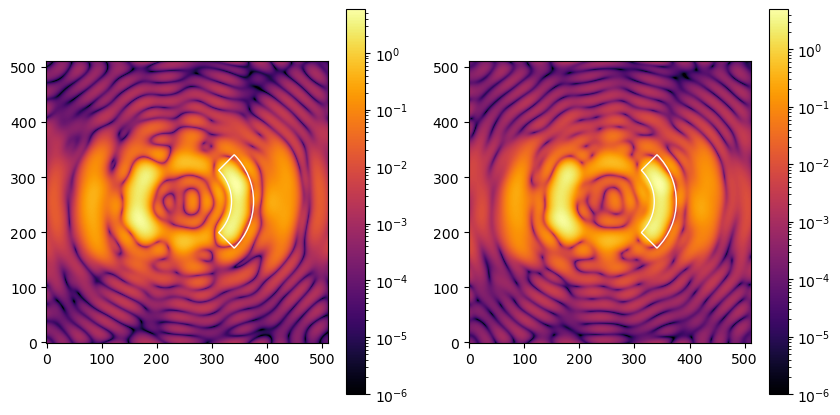

In [1686]:
from matplotlib.patches import Wedge
ref_contrast = snap_image(include_fpm=False).max()
vlim = 5
plt.figure(figsize=[10,10])
plt.subplot(221)
plt.title("Sine Probe")
plt.imshow(diff_imgs[0], cmap="RdBu_r", origin="lower", vmin=-vlim, vmax=vlim)
plt.colorbar()
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.ylabel("Difference Image")
plt.subplot(222)
plt.title("Cosine Probe")
plt.imshow(diff_imgs[1], cmap="RdBu_r", origin="lower", vmin=-vlim, vmax=vlim)
plt.colorbar()
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)

plt.subplot(223)
plt.imshow(dm_surfs[0], cmap="RdBu_r", origin="lower")
plt.colorbar()
plt.ylabel("DM Surface")
plt.subplot(224)
plt.imshow(dm_surfs[1], cmap="RdBu_r", origin="lower")
plt.colorbar()
plt.show()

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(fwd_imgs[0], cmap="inferno", norm=LogNorm(vmin=1e-6), origin="lower")
plt.colorbar()
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.subplot(122)
plt.imshow(fwd_imgs[1], cmap="inferno", norm=LogNorm(vmin=1e-6), origin="lower")
plt.colorbar()
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.show()

In [1687]:
# compute the delta images
I0 = snap_image(dm.render(wfe=True))
probe_images = []
for probe in [-sin_probe, sin_probe, -cos_probe, cos_probe]:

    dm.actuators[:] += probe
    img = snap_image(dm.render(wfe=True))
    dm.actuators[:] -= probe
    probe_images.append(img)

# Unpack
Im1 = probe_images[0]  # minus sin probe
Ip1 = probe_images[1]  # plus sin probe
Im2 = probe_images[2]  # minus cos probe
Ip2 = probe_images[3]  # plus cos probe

# Compute the relevant quantities
dI1 = Ip1 - Im1
dI2 = Ip2 - Im2

dE1 = dI1 / 4
dE1sq = (Ip1 + Im1 - 2*I0)
dE2 = dI2 / 4
dE2sq = (Ip2 + Im2 - 2*I0)

p = dI1 / (2 * dE1sq)
q = dI2 / (2 * dE2sq)

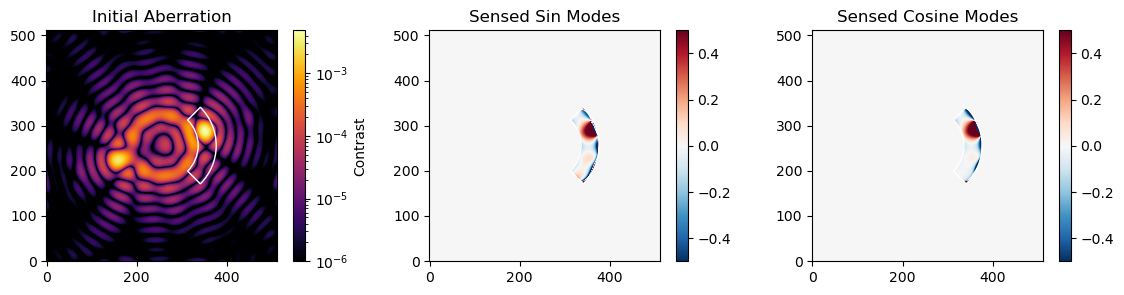

In [1688]:
ref_contrast = snap_image(include_fpm=False).max()
vlim = 0.5
plt.figure(figsize=[14, 3])
plt.subplot(131)
plt.title("Initial Aberration")
plt.imshow(I0 / ref_contrast, cmap="inferno", norm=LogNorm(vmin=1e-6), origin="lower")
plt.colorbar(label="Contrast")
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.subplot(132)
plt.title("Sensed Sin Modes")
plt.imshow(p * dark_hole, cmap="RdBu_r", vmin=-vlim, vmax=vlim, origin="lower")
plt.colorbar()
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.subplot(133)
plt.title("Sensed Cosine Modes")
plt.imshow(q * dark_hole, cmap="RdBu_r", vmin=-vlim, vmax=vlim, origin="lower")
plt.colorbar()
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.show()

# Apply the correction

In [1689]:
sin_correction = p[dark_hole==1, None, None] * V0 / V1norm * V1
cos_correction = q[dark_hole==1, None, None] * V0 / V2norm * V2


correction = sin_correction + cos_correction
correction = -np.sum(correction, axis=0)
dm.actuators[:] += correction
I_corrected = snap_image(dm.render(wfe=True))

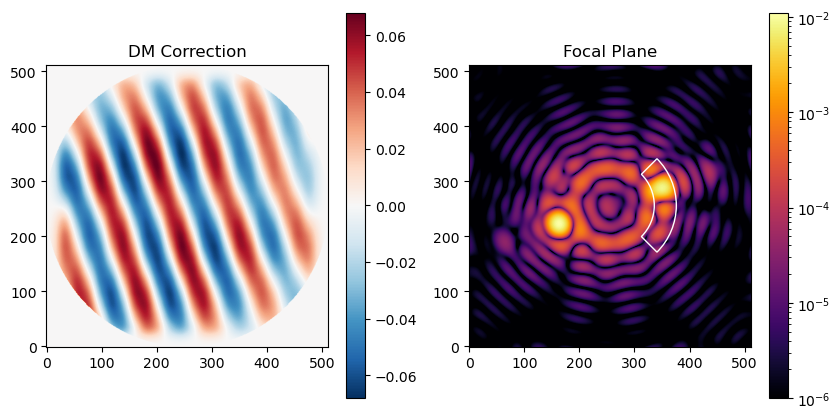

In [1690]:
plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(dm.render() * A, cmap="RdBu_r", origin="lower")
plt.colorbar()
plt.title("DM Correction")
plt.subplot(122)
plt.imshow(I_corrected / ref_contrast, norm=LogNorm(vmin=1e-6), cmap="inferno", origin="lower")
plt.colorbar()
plt.title("Focal Plane")
ax = plt.gca()
dh_region = Wedge([256, 256], OWA/(dx_img * um_to_LD),
                  theta1=-45, theta2=45, width=(OWA-IWA)/(dx_img * um_to_LD),
                  edgecolor="w", facecolor="None")
ax.add_patch(dh_region)
plt.show()